## Sparse logistic regression
$\newcommand{\n}[1]{\left\|#1 \right\|}$ 
$\newcommand{\R}{\mathbb R}            $ 
$\newcommand{\N}{\mathbb N}            $ 
$\newcommand{\Z}{\mathbb Z}            $ 
$\newcommand{\lr}[1]{\left\langle #1\right\rangle}$

We want to minimize
$$\min_x F(x) := \sum_{i=1}^m \log\bigl(1+\exp (-b_i\lr{a_i, x})\bigr) + \gamma \n{x}_1$$
where $(a_i, b_i)\in \R^n\times \{-1,1\}$ is the training set and $\gamma >0$. We can rewrite the objective as 
$F(x) = \tilde f(Kx)+g(x)$,
where $$\tilde f(y)=\sum_{i=1}^{} \log (1+\exp(y_i)), \quad K = -b*A \in \R^{m\times n}, \quad g(x) = \gamma \n{x}_1$$


In [4]:
import numpy as np
import scipy.linalg as LA
import scipy.sparse as spr
import scipy.sparse.linalg as spr_LA
from time import perf_counter
from sklearn import datasets

In [5]:
#filename = "data/a9a"
filename = "data/rcv1_train.binary.bz2"


A, b =  datasets.load_svmlight_file(filename)
m, n = A.shape

print("The dataset {}. The dimensions: m={}, n={}".format(filename[5:], m, n))

# define all ingredients for sparse logistic regression
gamma = 0.005 * LA.norm(A.T.dot(b), np.inf)
K = (A.T.multiply(-b)).T.tocsr()

# find the norm of K^T K
L = spr_LA.svds(K, k=1, return_singular_vectors=False)**2

# starting point
x0 = np.zeros(n)

# stepsize
ss = 4/L

g = lambda x: gamma*LA.norm(x,1)
prox_g = lambda x, rho: x + np.clip(-x, -rho*gamma, rho*gamma)


f = lambda x: np.log(1. + np.exp(x)).sum()

def df(x):
    exp_x = np.exp(x)
    return exp_x/(1.+exp_x)

dh = lambda x, Kx: K.T.dot(df(Kx))

# residual
res = lambda x: LA.norm(x-prox_g(x-dh(x,K.dot(x)), 1))

# energy
J = lambda x, Kx: f(Kx)+g(x)

def prox_T(z,v,x,k):
    l = k**2
    z1 = z - np.max(np.dot(v,z-x) / l, 0)*v
    return z1

The dataset rcv1_train.binary.bz2. The dimensions: m=20242, n=47236


In [6]:
### Algorithms

def explicit_graal(x1, phi, numb_iter=100):
    """
    Implementation of the explicit GRAAL.

    x1: array, a starting point
    numb_iter: positive integer, number of iterations

    Returns an array of energy values, computed in each iteration, and the
    argument x_k after numb_iter iterations
    """
    begin = perf_counter()
    phi = 1.5
    x, x_ = x1.copy(), x1.copy()
    x0 = x + np.random.randn(x.shape[0]) * 1e-9
    Kx = K.dot(x)
    dhx = dh(x, Kx)
    la = phi / 2 * LA.norm(x - x0) / LA.norm(dhx - dh(x0, K.dot(x0)))
    rho = 1. / phi + 1. / phi**2
    values = [J(x, Kx)]
    step_list = [la]
    tt= [0]
    th = 1

    for i in range(numb_iter):
        x1 = prox_g(x_ - la * dhx, la)
        Kx1 = K.dot(x1)
        dhx1 = dh(x1, Kx1)

        n1 = LA.norm(x1 - x)**2
        n2 = LA.norm(dhx1 - dhx)**2

        n1_div_n2 = n1/n2 if n2 != 0 else la*10
        la1 = min(rho * la, 0.25 * phi * th / la * (n1_div_n2))
        x_ = ((phi - 1) * x1 + x_) / phi
        #x_ = ((phi - 1) * x_ + x1) / phi
        th = phi * la1 / la
        x, la, dhx = x1, la1, dhx1
        values.append(J(x1, Kx1))
        step_list.append(la1)
        tt.append(perf_counter() - begin)

    end = perf_counter()

    print("Time execution of EGRAAL:", end - begin)
    return values, x, step_list,tt

def explicit_pgm(x1, phi, rho, numb_iter=100):
    """
    Implementation of the adaptive PGM with convex combination.

    x1: array, a starting point
    numb_iter: positive integer, number of iterations

    Returns an array of energy values, computed in each iteration, and the
    argument x_k after numb_iter iterations
    """
    begin = perf_counter()
    x, x_ = x1.copy(), x1.copy()
    x0 = x + np.random.randn(x.shape[0]) * 1e-9
    Kx = K.dot(x)
    dhx = dh(x, Kx)
    la = phi / 2 * LA.norm(x - x0) / LA.norm(dhx - dh(x0, K.dot(x0)))
    xi = phi-phi**3*rho /(2*(1+phi))
    print('xi=', xi)
    values = [J(x, Kx)]
    step_list = [la]
    tt = [0]
    th = 1

    for i in range(numb_iter):
        x1 = prox_g(x_ - la * dhx, la)
        Kx1 = K.dot(x1)
        dhx1 = dh(x1, Kx1)

        n1 = LA.norm(x1 - x)**2
        n2 = LA.norm(dhx1 - dhx)**2

        n1_div_n2 = n1/n2 if n2 != 0 else la*10
        la1 = min(rho * la, xi**2 * th / la * (n1_div_n2))
        
        x_ = ((phi - 1) * x1 + x_) / phi
        th = la1 / la
        x, la, dhx = x1, la1, dhx1
        values.append(J(x1, Kx1))
        step_list.append(la1)
        tt.append(perf_counter() - begin)

    end = perf_counter()

    print("Time execution of aPGMc:", end - begin)
    return values, x, step_list,tt

Run the algorithms. It might take some time, if the dataset and/or the number of iterations are huge

In [7]:
N = 10000
ans3 = explicit_graal(x0, phi=1.5, numb_iter=N)
ans4 = explicit_pgm(x0,  phi=2,rho = 10/9, numb_iter=N)
ans5 = explicit_pgm(x0,  phi=2,rho = 6/5, numb_iter=N)


Time execution of EGRAAL: 70.65221369999999
xi= 0.5185185185185184
Time execution of aPGMc: 77.84065210000001
xi= 0.40000000000000013
Time execution of aPGMc: 72.9061869


Plot the results

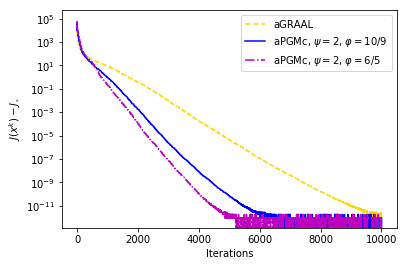

In [9]:
import matplotlib.pyplot as plt
values = [ans3[0], ans4[0], ans5[0]]
labels = ["aGRAAL",r"aPGMc, $\psi=2$, $\varphi=10/9$",r"aPGMc, $\psi=2$, $\varphi=6/5$"]
linestyles = [ "--", "-", "-."]
colors = ['#FFD700','b','m']

v_min = min([min(v) for v in values])
plt.figure(figsize=(6,4))
for i,v in enumerate(values):
    plt.plot(v - v_min, color=colors[i], label=labels[i], linestyle=linestyles[i])
plt.yscale('log')
plt.xlabel(u'Iterations')
plt.ylabel('$J(x^k)-J_{_*}$')
plt.legend()
#plt.savefig('figures/a9a.pdf', bbox_inches='tight')
plt.show()


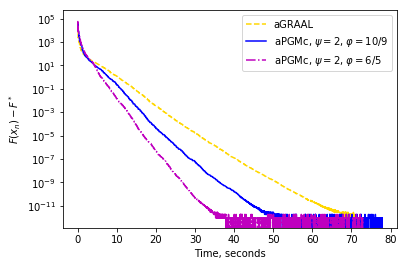

In [10]:
import matplotlib.pyplot as plt
tt = [ans3[-1], ans4[-1], ans5[-1]]
values = [ans3[0], ans4[0], ans5[0]]
labels = ["aGRAAL",r"aPGMc, $\psi=2$, $\varphi=10/9$",r"aPGMc, $\psi=2$, $\varphi=6/5$"]
linestyles = [ "--", "-", "-."]
colors = ['#FFD700','b','m']


v_min = min([min(v) for v in values])
fig = plt.figure()
for i,v in enumerate(values):
    plt.plot(tt[i], v-v_min, color=colors[i], label=labels[i], linestyle=linestyles[i])
plt.yscale('log')
plt.xlabel(u'Time, seconds')
plt.ylabel('$F(x_n)-F^*$')
plt.legend()
#plt.axis([-1,20,1e-13,1e+5])

plt.show()

#fig.savefig('figures/a9a-time.pdf')
#fig.savefig('figures/real-sim.pdf')
#fig.savefig('figures/rcv1-time.pdf')

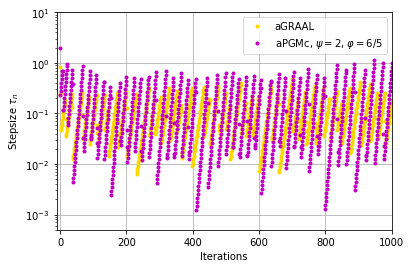

In [13]:
plt.ticklabel_format(style='sci',scilimits=(0,0),axis='y')
plt.plot(ans3[-2], '.', color='#FFD700', label="aGRAAL")
#plt.plot(ans3[-1], '.', color='r',  label="EGRAAL_Non")
plt.plot(ans5[-2], '.', color='m',  label=r"aPGMc, $\psi=2$, $\varphi=6/5$")

plt.legend()
plt.xlim(0,N)
#plt.ylim(0)

plt.xlabel(u'Iterations')
plt.ylabel(r'Stepsize $\tau_n$')
plt.yscale('log')
plt.axis([-10, 1000, 5e-4, 1e+1])
plt.legend()
plt.grid()
#plt.savefig('figures/a9a-steps.pdf',bbox_inches='tight')
#plt.savefig('figures/rcv1-steps.pdf',bbox_inches='tight')
plt.show()
#plt.clf()